In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import root_mean_squared_error,r2_score,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


In [ ]:
from google .colab import files
data=files.upload()

Saving E-commerce Customer Behavior - Sheet1.csv to E-commerce Customer Behavior - Sheet1 (1).csv


In [ ]:
df=pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')

`data cleaning /preprocessing `

In [ ]:
df['Membership Type'].head()

,Membership Type
0,Gold
1,Silver
2,Bronze
3,Gold
4,Silver


In [ ]:
df.shape

(350, 11)

In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df['Satisfaction Level'].isnull()]

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
71,172,Female,37,Houston,Bronze,420.8,7,3.1,False,21,NaN
143,244,Female,37,Houston,Bronze,430.8,7,3.4,False,23,NaN


filling missing value in satisfaction column

In [116]:
filling=df['Satisfaction Level'].mode()[0]
df['Satisfaction Level']=df['Satisfaction Level'].fillna(filling)

In [117]:
df['Satisfaction Level'].isnull().sum()

np.int64(0)

In [ ]:
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [ ]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


`checking outlier`

In [ ]:
def check_outliers(dataframe, column_name):
    # 1. Calculate the 25th and 75th percentiles (Q1 and Q3)
    q1 = dataframe[column_name].quantile(0.25)
    q3 = dataframe[column_name].quantile(0.75)

    # 2. Compute the Interquartile Range (IQR)
    iqr = q3 - q1

    # 3. Define the fences (boundaries)
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)

    # 4. Count how many data points fall outside the fences
    min_outliers = dataframe[dataframe[column_name] < lower_fence].shape[0]
    max_outliers = dataframe[dataframe[column_name] > upper_fence].shape[0]

    # 5. Display the diagnostic report
    print(f"📊 --- Outlier Report for '{column_name}' ---")
    print(f"Lower Fence (Min Limit): {lower_fence:.2f} | Found: {min_outliers} minimum outliers")
    print(f"Upper Fence (Max Limit): {upper_fence:.2f} | Found: {max_outliers} maximum outliers")
    print(f"Total Outliers in Column: {min_outliers + max_outliers}\n")
    # Check your Total Spend column
check_outliers(df, 'Total Spend')

# Check your Days Since Last Purchase column
check_outliers(df, 'Days Since Last Purchase')

📊 --- Outlier Report for 'Total Spend' ---
Lower Fence (Min Limit): -485.90 | Found: 0 minimum outliers
Upper Fence (Max Limit): 2148.50 | Found: 0 maximum outliers
Total Outliers in Column: 0

📊 --- Outlier Report for 'Days Since Last Purchase' ---
Lower Fence (Min Limit): -19.50 | Found: 0 minimum outliers
Upper Fence (Max Limit): 72.50 | Found: 0 maximum outliers
Total Outliers in Column: 0



`eda`

`numerical column`
- age
- total spen
- rating
- discount
- last purchased
- item purchased


`categorical col`
- gender
- city
-  member ship type
- satisfaction level

In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

<Axes: xlabel='Total Spend', ylabel='Average Rating'>

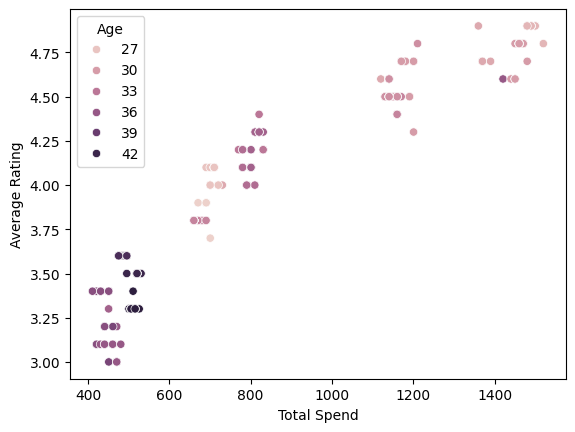

In [ ]:
sns.scatterplot(data=df,x='Total Spend',y='Average Rating',hue='Age')
#the the 4.75 rating given by person is age of 27 and spend most money

In [ ]:
sns.scatterplot(data=df,x='Total Spend',y='Age')
#the most money spend by person is age of 28

<Axes: xlabel='Total Spend', ylabel='Items Purchased'>

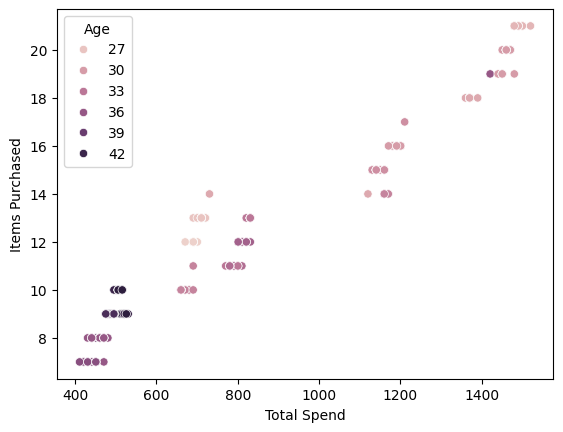

In [ ]:
sns.scatterplot(data=df,x='Total Spend',y='Items Purchased',hue='Age')
#more item more spend by 27 age person

<Axes: xlabel='Total Spend', ylabel='Days Since Last Purchase'>

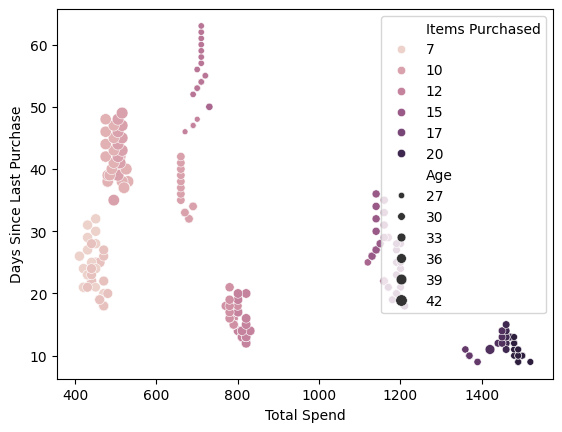

In [ ]:
sns.scatterplot(data=df,x='Total Spend',y='Days Since Last Purchase',hue='Items Purchased',size='Age')
#so most item are buyed 10 days before number of item are 17 -- 20

<Axes: xlabel='Total Spend', ylabel='Membership Type'>

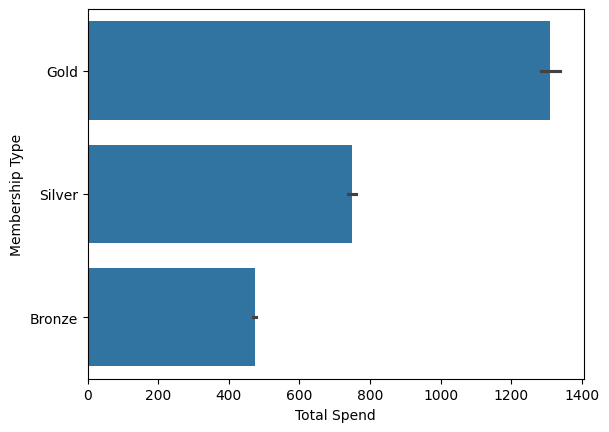

In [ ]:
sns.barplot(data=df,x='Total Spend',y='Membership Type')

<Axes: xlabel='Age', ylabel='Satisfaction Level'>

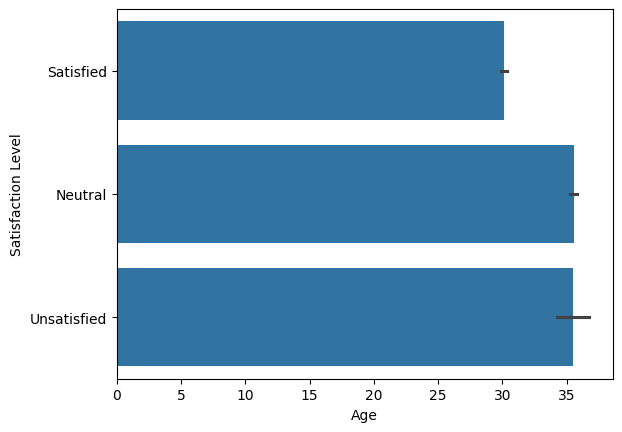

In [ ]:

sns.barplot(data=df,x='Age',y='Satisfaction Level')
#almost equal number

<Axes: xlabel='Total Spend', ylabel='City'>

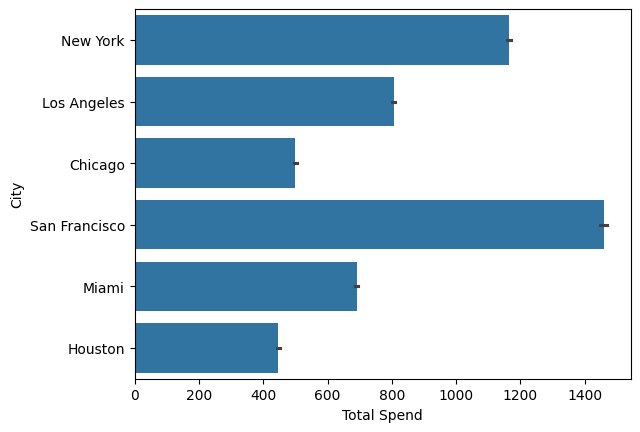

In [ ]:
sns.barplot(data=df,x='Total Spend',y='City')
#the most spend is done by san francisco city and leat by houston

feature engineering
* encoding
  - one hot encoding
     - gender
     - ciy
     
  - ordinal encoding
     - membership type     
     - satisfaction level
* standarization

In [ ]:
df_cp=df.copy()

`encoding`

In [ ]:
df_cp=pd.get_dummies(df_cp,columns=['Gender','City'],dtype=int)

In [ ]:
ordinal={'Gold':0,'Silver':1,'Bronze':2}
df_cp['Membership Type']=df['Membership Type'].map(ordinal)

In [ ]:
ordinal2={'Unsatisfied':0,'Neutral':1,'Satisfied':2}
df_cp['Satisfaction Level']=df_cp['Satisfaction Level'].map(ordinal2)

In [ ]:
df_cp['Discount Applied'] = df_cp['Discount Applied'].astype(int)

`standarization`

In [ ]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [ ]:
numeric_col=['Age','Total Spend','Items Purchased','Average Rating','Days Since Last Purchase']
scaler=StandardScaler()
df_cp[numeric_col]=scaler.fit_transform(df_cp[numeric_col])

In [ ]:
df_cp


,Customer ID,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Gender_Female,Gender_Male,City_Chicago,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
0,101,-0.945152,0,0.760130,0.337346,1.001981,1,-0.118359,2.0,1,0,0,0,0,0,1,0
1,102,0.082826,1,-0.179459,-0.385538,0.139479,0,-0.639907,1.0,0,1,0,0,1,0,0,0
2,103,1.933185,2,-0.925570,-0.867461,-1.068024,1,1.148256,0.0,1,0,1,0,0,0,0,0
3,104,-0.739557,0,1.756144,1.542153,1.174482,0,-1.086947,2.0,0,1,0,0,0,0,0,1
4,105,-1.356343,1,-0.345692,0.096385,-0.033022,1,2.116844,0.0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,446,-0.328365,1,-0.511924,-0.626500,-0.378022,1,1.148256,0.0,0,1,0,0,0,1,0,0
346,447,0.494017,2,-1.036899,-1.108422,-1.758026,0,0.030654,1.0,1,0,0,1,0,0,0,0
347,448,-0.739557,0,0.955405,0.819269,0.829481,1,0.105161,2.0,1,0,0,0,0,0,1,0
348,449,0.082826,1,-0.180289,-0.385538,0.311979,0,-0.416386,1.0,0,1,0,0,1,0,0,0


`model implementation `

In [128]:
X=df_cp.drop(columns=['Total Spend'])
y=df_cp['Total Spend']

In [122]:
#filling value in copy col
fill=df_cp['Satisfaction Level'].mode()[0]
df_cp['Satisfaction Level']=df_cp['Satisfaction Level'].fillna(fill)

In [129]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [130]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [131]:
y_pred=model.predict(X_test)

In [133]:
rmse=rmse=np.sqrt(root_mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)

In [134]:
print("--- Model Training Successful! ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Total Spend")
print(f"R-squared (R²) Score: {r2:.4f} ({r2*100:.1f}% of variance explained)")

--- Model Training Successful! ---
Root Mean Squared Error (RMSE): 0.21 Total Spend
R-squared (R²) Score: 0.9981 (99.8% of variance explained)


In [136]:
# Create a dataframe to store features and their corresponding weights
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': model.coef_
})

# Sort by the absolute impact so the heaviest drivers are at the top
coefficients['Absolute_Impact'] = coefficients['Coefficient (Weight)'].abs()
coefficients = coefficients.sort_values(by='Absolute_Impact', ascending=False).drop(columns=['Absolute_Impact'])

print(f"Base Intercept: {model.intercept_:.2f}\n")
print("--- Feature Coefficients ---")
print(coefficients.to_string(index=False))

Base Intercept: 0.74

--- Feature Coefficients ---
                 Feature  Coefficient (Weight)
         Membership Type             -0.673092
      City_San Francisco              0.420990
         Items Purchased              0.281931
              City_Miami             -0.257263
        City_Los Angeles             -0.165116
            City_Houston             -0.141903
           City_New York              0.126745
        Discount Applied             -0.113971
Days Since Last Purchase             -0.053004
      Satisfaction Level             -0.025159
                     Age              0.017139
            City_Chicago              0.016547
           Gender_Female             -0.016298
             Gender_Male              0.016298
          Average Rating              0.007506
             Customer ID              0.000046


In [138]:
import numpy as np
import pandas as pd
import warnings

# Suppress warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("🛍️ --- E-commerce Customer Spend Predictor --- 🛍️")
print("Please enter the following details:\n")

# # 1. Collect inputs dynamically from the user
new_age = float(input("Enter Age: "))
items_purchased = float(input("Enter Items Purchased: "))
avg_rating = float(input("Enter Average Rating: "))
days_since_purchase = float(input("Enter Days Since Last Purchase: "))

print("\n--- Membership Types ---")
membership = input("Enter Membership Type (Gold, Silver, Bronze): ").strip().capitalize()

print("\n--- Satisfaction Levels ---")
satisfaction = input("Enter Satisfaction Level (Satisfied, Neutral, Unsatisfied): ").strip().capitalize()

print("\n--- Cities ---")
city = input("Enter City (New York, Los Angeles, Chicago, San Francisco, Miami, Houston): ").strip().title()

print("\n--- Gender ---")
gender = input("Enter Gender (Male/Female): ").strip().capitalize()

print("\n--- Promotions ---")
discount_input = input("Was a discount applied? (Yes/No): ").strip().lower()

# # 2. Map categorical and text values
# Ordinal mapping
ordinal_membership = {'Gold': 0, 'Silver': 1, 'Bronze': 2}.get(membership, 2)
ordinal_satisfaction = {'Unsatisfied': 0, 'Neutral': 1, 'Satisfied': 2}.get(satisfaction, 1)

# Boolean mapping
discount_applied = 1 if discount_input in ['yes', 'y', 'true'] else 0

# One-hot encoding cities
city_chicago = 1 if city == "Chicago" else 0
city_houston = 1 if city == "Houston" else 0
city_los_angeles = 1 if city == "Los Angeles" else 0
city_miami = 1 if city == "Miami" else 0
city_new_york = 1 if city == "New York" else 0
city_san_francisco = 1 if city == "San Francisco" else 0

# One-hot encoding gender
gender_female = 1 if gender == "Female" else 0
gender_male = 1 if gender == "Male" else 0

# # 3. Create a dictionary of all your processed features
input_data = {
    'Age': new_age,
    'Membership Type': ordinal_membership,
    'Items Purchased': items_purchased,
    'Average Rating': avg_rating,
    'Discount Applied': discount_applied,
    'Days Since Last Purchase': days_since_purchase,
    'Satisfaction Level': ordinal_satisfaction,
    'Gender_Female': gender_female,
    'Gender_Male': gender_male,
    'City_Chicago': city_chicago,
    'City_Houston': city_houston,
    'City_Los Angeles': city_los_angeles,
    'City_Miami': city_miami,
    'City_New York': city_new_york,
    'City_San Francisco': city_san_francisco
}

# Convert to DataFrame and automatically align with the exact columns and order of X
new_features = pd.DataFrame([input_data])
new_features = new_features.reindex(columns=X.columns, fill_value=0)

# 5. Predict the total spend!
predicted_spend = model.predict(new_features)[0]

print("\n----------------------------------------")
print(f"💰 Estimated Total Spend: ${predicted_spend:.2f}")
print("----------------------------------------")

🛍️ --- E-commerce Customer Spend Predictor --- 🛍️
Please enter the following details:

Enter Age: 18
Enter Items Purchased: 4
Enter Average Rating: 5
Enter Days Since Last Purchase: 3

--- Membership Types ---
Enter Membership Type (Gold, Silver, Bronze): silver

--- Satisfaction Levels ---
Enter Satisfaction Level (Satisfied, Neutral, Unsatisfied): neutral

--- Cities ---
Enter City (New York, Los Angeles, Chicago, San Francisco, Miami, Houston): new york

--- Gender ---
Enter Gender (Male/Female): female

--- Promotions ---
Was a discount applied? (Yes/No): no

----------------------------------------
💰 Estimated Total Spend: $1.47
----------------------------------------
